<a href="https://colab.research.google.com/github/tharunarasu/Atri-AI/blob/main/AtriAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Test Images Shape     : (10000, 28, 28)
Test Labels Shape     : (10000,)


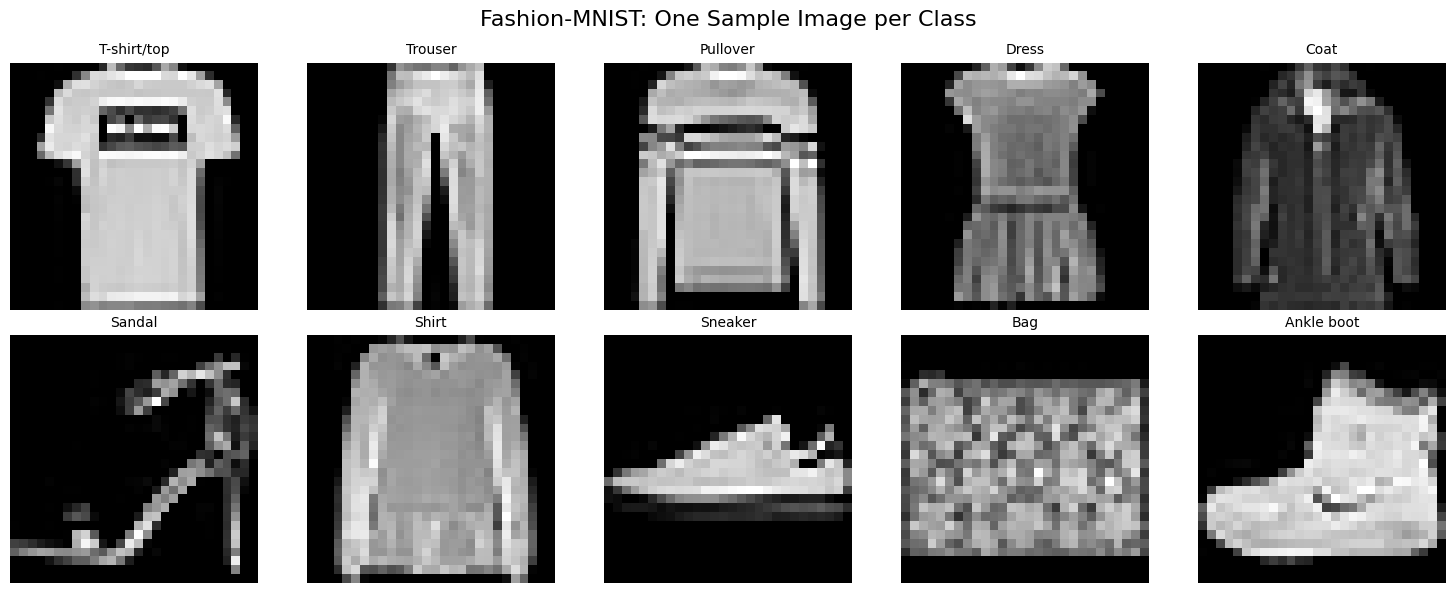

In [ ]:

from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Dataset information
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Test Images Shape     :", X_test.shape)
print("Test Labels Shape     :", y_test.shape)

# Fashion-MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Create figure
plt.figure(figsize=(15, 6))

# Plot one sample image from each class
for label in range(10):

    # Find first occurrence of the class
    idx = np.where(y_train == label)[0][0]

    # Plot image
    plt.subplot(2, 5, label + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(class_names[label], fontsize=10)
    plt.axis('off')

plt.suptitle("Fashion-MNIST: One Sample Image per Class", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

class NeuralNetwork:

    def __init__(
        self,
        input_size,
        hidden_layers,
        output_size
    ):

        layer_sizes = (
            [input_size]
            + hidden_layers
            + [output_size]
        )

        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes)-1):

            W = (
                np.random.randn(
                    layer_sizes[i],
                    layer_sizes[i+1]
                ) * 0.01
            )

            b = np.zeros(
                (1,layer_sizes[i+1])
            )

            self.weights.append(W)
            self.biases.append(b)

    def sigmoid(self,x):

        return 1/(1+np.exp(-x))

    def softmax(self,z):

        z = z - np.max(
            z,
            axis=1,
            keepdims=True
        )

        exp_z = np.exp(z)

        return exp_z/np.sum(
            exp_z,
            axis=1,
            keepdims=True
        )

    def forward(self,X):

        self.activations = [X]

        A = X

        for i in range(
            len(self.weights)-1
        ):

            Z = (
                np.dot(
                    A,
                    self.weights[i]
                )
                +
                self.biases[i]
            )

            A = self.sigmoid(Z)

            self.activations.append(A)

        Z = (
            np.dot(
                A,
                self.weights[-1]
            )
            +
            self.biases[-1]
        )

        output = self.softmax(Z)

        self.activations.append(output)

        return output

In [ ]:
nn = NeuralNetwork(
        input_size=784,
        hidden_layers=[128,128,128],
        output_size=10
)

sample_X = X_train[:5].reshape(-1, 784) / 255.0
pred = nn.forward(sample_X)

print(pred.shape)


In [ ]:
import numpy as np
from keras.datasets import fashion_mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Flatten and normalize
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (60000, 784)
X_test shape : (10000, 784)


In [ ]:
class NeuralNetwork:

    def __init__(self, input_size, hidden_layers, output_size):

        layer_sizes = [input_size] + hidden_layers + [output_size]

        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes) - 1):

            W = np.random.randn(
                layer_sizes[i],
                layer_sizes[i+1]
            ) * np.sqrt(1.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i + 1]))

            self.weights.append(W)
            self.biases.append(b)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def softmax(self, z):

        z = z - np.max(z, axis=1, keepdims=True)

        exp_z = np.exp(z)

        return exp_z / np.sum(
            exp_z,
            axis=1,
            keepdims=True
        )

    def forward(self, X):

        self.activations = [X]

        A = X

        # Hidden layers
        for i in range(len(self.weights) - 1):

            Z = np.dot(A, self.weights[i]) + self.biases[i]

            A = self.sigmoid(Z)

            self.activations.append(A)

        # Output layer
        Z = np.dot(A, self.weights[-1]) + self.biases[-1]

        output = self.softmax(Z)

        self.activations.append(output)

        return output

In [ ]:
nn = NeuralNetwork(
    input_size=784,
    hidden_layers=[128, 128, 128],
    output_size=10
)

pred = nn.forward(X_train[:5])

print("Prediction shape:", pred.shape)

print("\nFirst prediction:")
print(pred[0])

print("\nSum of probabilities:")
print(np.sum(pred[0]))

Prediction shape: (5, 10)

First prediction:
[0.08565701 0.07144646 0.05941968 0.07124537 0.07902499 0.36783194
 0.07589511 0.07401173 0.07994133 0.03552637]

Sum of probabilities:
1.0


In [ ]:
import numpy as np

def one_hot(y, num_classes=10):

    Y = np.zeros((len(y), num_classes))

    Y[np.arange(len(y)), y] = 1

    return Y

In [ ]:
def cross_entropy(y_true, y_pred):

    epsilon = 1e-10

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    return -np.mean(
        np.sum(
            y_true * np.log(y_pred),
            axis=1
        )
    )


def accuracy(y_true, y_pred):

    y_pred_labels = np.argmax(y_pred, axis=1)

    y_true_labels = np.argmax(y_true, axis=1)

    return np.mean(y_pred_labels == y_true_labels)


In [ ]:
class NeuralNetwork:

    def __init__(self,
                 input_size,
                 hidden_layers,
                 output_size):

        layer_sizes = (
            [input_size]
            + hidden_layers
            + [output_size]
        )

        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes)-1):

            W = np.random.randn(
                layer_sizes[i],
                layer_sizes[i+1]
            ) * 0.01

            b = np.zeros(
                (1, layer_sizes[i+1])
            )

            self.weights.append(W)
            self.biases.append(b)

    def sigmoid(self, x):

        return 1/(1+np.exp(-x))

    def sigmoid_derivative(self, A):

        return A*(1-A)

    def softmax(self, z):

        z = z - np.max(
            z,
            axis=1,
            keepdims=True
        )

        exp_z = np.exp(z)

        return exp_z / np.sum(
            exp_z,
            axis=1,
            keepdims=True
        )

    def forward(self, X):

        self.activations = [X]

        A = X

        for i in range(len(self.weights)-1):

            Z = (
                np.dot(
                    A,
                    self.weights[i]
                )
                +
                self.biases[i]
            )

            A = self.sigmoid(Z)

            self.activations.append(A)

        Z = (
            np.dot(
                A,
                self.weights[-1]
            )
            +
            self.biases[-1]
        )

        output = self.softmax(Z)

        self.activations.append(output)

        return output

    def backward(self, X, y):

        m = X.shape[0]

        self.dW = [None] * len(self.weights)
        self.db = [None] * len(self.biases)

        delta = (
            self.activations[-1]
            - y
        )

        for i in reversed(
            range(len(self.weights))
        ):

            self.dW[i] = (
                np.dot(
                    self.activations[i].T,
                    delta
                ) / m
            )

            self.db[i] = (
                np.sum(
                    delta,
                    axis=0,
                    keepdims=True
                ) / m
            )

            if i > 0:

                delta = np.dot(
                    delta,
                    self.weights[i].T
                )

                delta *= (
                    self.sigmoid_derivative(
                        self.activations[i]
                    )
                )

    def update_sgd(
        self,
        learning_rate
    ):

        for i in range(
            len(self.weights)
        ):

            self.weights[i] -= (
                learning_rate
                * self.dW[i]
            )

            self.biases[i] -= (
                learning_rate
                * self.db[i]
            )

    def train(
        self,
        X,
        y,
        epochs,
        learning_rate
    ):

        for epoch in range(epochs):

            predictions = self.forward(X)

            loss = cross_entropy(
                y,
                predictions
            )

            self.backward(
                X,
                y
            )

            self.update_sgd(
                learning_rate
            )

            acc = accuracy(y, predictions)

            print(
                  f"Epoch {epoch+1}/{epochs} "
                  f"Loss={loss:.4f} "
                  f"Acc={acc:.4f}"
              )

In [ ]:
Y_train = one_hot(y_train)

print(Y_train.shape)

(60000, 10)


In [ ]:
nn = NeuralNetwork(
    input_size=784,
    hidden_layers=[128,128],
    output_size=10
)

nn.train(
    X_train[:1000],
    Y_train[:1000],
    epochs=5,
    learning_rate=0.01
)

In [ ]:
nn = NeuralNetwork(
    input_size=784,
    hidden_layers=[128,128],
    output_size=10
)

nn.train(
    X_train[:5000],
    Y_train[:5000],
    epochs=20,
    learning_rate=0.1
)

In [ ]:
def accuracy(y_true, y_pred):

    y_pred_labels = np.argmax(y_pred, axis=1)

    y_true_labels = np.argmax(y_true, axis=1)

    return np.mean(y_pred_labels == y_true_labels)

In [ ]:
pred = nn.forward(X_train[:1000])

print(np.max(pred))
print(np.min(pred))
print(pred[0])

In [ ]:
print(nn.dW[0].mean())
print(nn.dW[0].std())

In [ ]:
def update_momentum(self, lr, beta=0.9):

    if not hasattr(self, "vW"):
        self.vW = [np.zeros_like(w) for w in self.weights]
        self.vb = [np.zeros_like(b) for b in self.biases]

    for i in range(len(self.weights)):

        self.vW[i] = beta*self.vW[i] + self.dW[i]
        self.vb[i] = beta*self.vb[i] + self.db[i]

        self.weights[i] -= lr*self.vW[i]
        self.biases[i] -= lr*self.vb[i]

## Final Q3-Q6 implementation

The cells below are the clean, flexible implementation for Questions 3 to 6. They keep the earlier exploratory cells above, but this section is the one to use for training, sweeps, plots, and report observations.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import wandb
except ImportError:
    wandb = None

np.random.seed(42)

# Re-load only if these variables are missing in a fresh kernel.
try:
    X_train_raw, y_train_raw, X_test_raw, y_test_raw
except NameError:
    from keras.datasets import fashion_mnist
    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

# If earlier cells used X_train for flattened data, preserve a clean raw copy here.
if 'X_train_raw' not in globals():
    if X_train.ndim == 3:
        X_train_raw, y_train_raw = X_train.copy(), y_train.copy()
        X_test_raw, y_test_raw = X_test.copy(), y_test.copy()

def prepare_data(validation_fraction=0.10, seed=42):
    rng = np.random.default_rng(seed)

    X = X_train_raw.reshape(-1, 784).astype(np.float64) / 255.0
    X_te = X_test_raw.reshape(-1, 784).astype(np.float64) / 255.0
    y = y_train_raw.astype(int)
    y_te = y_test_raw.astype(int)

    indices = rng.permutation(len(X))
    val_size = int(validation_fraction * len(X))
    val_idx = indices[:val_size]
    train_idx = indices[val_size:]

    return (
        X[train_idx], y[train_idx],
        X[val_idx], y[val_idx],
        X_te, y_te
    )

def one_hot_labels(y, num_classes=10):
    encoded = np.zeros((len(y), num_classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded

X_train_final, y_train_final, X_val_final, y_val_final, X_test_final, y_test_final = prepare_data()
Y_train_final = one_hot_labels(y_train_final)
Y_val_final = one_hot_labels(y_val_final)
Y_test_final = one_hot_labels(y_test_final)

print('Train:', X_train_final.shape, Y_train_final.shape)
print('Validation:', X_val_final.shape, Y_val_final.shape)
print('Test:', X_test_final.shape, Y_test_final.shape)

In [ ]:
class FlexibleNeuralNetwork:
    def __init__(
        self,
        input_size=784,
        hidden_layers=(128, 128),
        output_size=10,
        activation='relu',
        weight_init='xavier',
        weight_decay=0.0,
        seed=42,
    ):
        self.layer_sizes = [input_size] + list(hidden_layers) + [output_size]
        self.activation_name = activation
        self.weight_init = weight_init
        self.weight_decay = weight_decay
        self.rng = np.random.default_rng(seed)
        self.weights = []
        self.biases = []
        self.reset_parameters()
        self.reset_optimizer_state()

    def reset_parameters(self):
        self.weights = []
        self.biases = []
        for fan_in, fan_out in zip(self.layer_sizes[:-1], self.layer_sizes[1:]):
            if self.weight_init == 'xavier':
                limit = np.sqrt(6.0 / (fan_in + fan_out))
                W = self.rng.uniform(-limit, limit, size=(fan_in, fan_out))
            elif self.weight_init == 'he':
                W = self.rng.normal(0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out))
            else:
                W = self.rng.normal(0, 0.01, size=(fan_in, fan_out))
            b = np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)

    def reset_optimizer_state(self):
        self.velocity_w = [np.zeros_like(w) for w in self.weights]
        self.velocity_b = [np.zeros_like(b) for b in self.biases]
        self.cache_w = [np.zeros_like(w) for w in self.weights]
        self.cache_b = [np.zeros_like(b) for b in self.biases]
        self.m_w = [np.zeros_like(w) for w in self.weights]
        self.m_b = [np.zeros_like(b) for b in self.biases]
        self.v_w = [np.zeros_like(w) for w in self.weights]
        self.v_b = [np.zeros_like(b) for b in self.biases]
        self.t = 0

    def activation(self, z):
        if self.activation_name == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        if self.activation_name == 'tanh':
            return np.tanh(z)
        if self.activation_name == 'relu':
            return np.maximum(0, z)
        raise ValueError(f'Unknown activation: {self.activation_name}')

    def activation_derivative(self, activated):
        if self.activation_name == 'sigmoid':
            return activated * (1.0 - activated)
        if self.activation_name == 'tanh':
            return 1.0 - activated**2
        if self.activation_name == 'relu':
            return (activated > 0).astype(float)
        raise ValueError(f'Unknown activation: {self.activation_name}')

    @staticmethod
    def softmax(z):
        shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        self.activations = [X]
        A = X
        for W, b in zip(self.weights[:-1], self.biases[:-1]):
            A = self.activation(A @ W + b)
            self.activations.append(A)
        logits = A @ self.weights[-1] + self.biases[-1]
        output = self.softmax(logits)
        self.activations.append(output)
        return output

    def loss(self, y_true, y_pred, loss_name='cross_entropy'):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1.0 - eps)
        if loss_name == 'cross_entropy':
            data_loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        elif loss_name == 'squared_error':
            data_loss = np.mean(np.sum((y_true - y_pred) ** 2, axis=1))
        else:
            raise ValueError(f'Unknown loss: {loss_name}')
        l2 = 0.5 * self.weight_decay * sum(np.sum(w * w) for w in self.weights)
        return data_loss + l2

    def backward(self, y_true, loss_name='cross_entropy'):
        m = y_true.shape[0]
        y_pred = self.activations[-1]
        if loss_name == 'cross_entropy':
            delta = (y_pred - y_true) / m
        else:
            delta = 2.0 * (y_pred - y_true) * y_pred * (1.0 - y_pred) / m

        self.dW = [None] * len(self.weights)
        self.db = [None] * len(self.biases)

        for i in reversed(range(len(self.weights))):
            self.dW[i] = self.activations[i].T @ delta + self.weight_decay * self.weights[i]
            self.db[i] = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.activation_derivative(self.activations[i])

    def update(self, optimizer='sgd', learning_rate=1e-3, beta=0.9, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.t += 1
        for i in range(len(self.weights)):
            if optimizer == 'sgd':
                step_w = self.dW[i]
                step_b = self.db[i]
            elif optimizer == 'momentum':
                self.velocity_w[i] = beta * self.velocity_w[i] + self.dW[i]
                self.velocity_b[i] = beta * self.velocity_b[i] + self.db[i]
                step_w = self.velocity_w[i]
                step_b = self.velocity_b[i]
            elif optimizer == 'nesterov':
                previous_vw = self.velocity_w[i].copy()
                previous_vb = self.velocity_b[i].copy()
                self.velocity_w[i] = beta * self.velocity_w[i] + self.dW[i]
                self.velocity_b[i] = beta * self.velocity_b[i] + self.db[i]
                step_w = -beta * previous_vw + (1 + beta) * self.velocity_w[i]
                step_b = -beta * previous_vb + (1 + beta) * self.velocity_b[i]
            elif optimizer == 'rmsprop':
                self.cache_w[i] = beta * self.cache_w[i] + (1 - beta) * (self.dW[i] ** 2)
                self.cache_b[i] = beta * self.cache_b[i] + (1 - beta) * (self.db[i] ** 2)
                step_w = self.dW[i] / (np.sqrt(self.cache_w[i]) + epsilon)
                step_b = self.db[i] / (np.sqrt(self.cache_b[i]) + epsilon)
            elif optimizer == 'adam':
                step_w, step_b = self._adam_step(i, beta1, beta2, epsilon, nadam=False)
            elif optimizer == 'nadam':
                step_w, step_b = self._adam_step(i, beta1, beta2, epsilon, nadam=True)
            else:
                raise ValueError(f'Unknown optimizer: {optimizer}')

            self.weights[i] -= learning_rate * step_w
            self.biases[i] -= learning_rate * step_b

    def _adam_step(self, i, beta1, beta2, epsilon, nadam=False):
        self.m_w[i] = beta1 * self.m_w[i] + (1 - beta1) * self.dW[i]
        self.m_b[i] = beta1 * self.m_b[i] + (1 - beta1) * self.db[i]
        self.v_w[i] = beta2 * self.v_w[i] + (1 - beta2) * (self.dW[i] ** 2)
        self.v_b[i] = beta2 * self.v_b[i] + (1 - beta2) * (self.db[i] ** 2)

        m_w_hat = self.m_w[i] / (1 - beta1 ** self.t)
        m_b_hat = self.m_b[i] / (1 - beta1 ** self.t)
        v_w_hat = self.v_w[i] / (1 - beta2 ** self.t)
        v_b_hat = self.v_b[i] / (1 - beta2 ** self.t)

        if nadam:
            grad_w_hat = self.dW[i] / (1 - beta1 ** self.t)
            grad_b_hat = self.db[i] / (1 - beta1 ** self.t)
            m_w_hat = beta1 * m_w_hat + (1 - beta1) * grad_w_hat
            m_b_hat = beta1 * m_b_hat + (1 - beta1) * grad_b_hat

        step_w = m_w_hat / (np.sqrt(v_w_hat) + epsilon)
        step_b = m_b_hat / (np.sqrt(v_b_hat) + epsilon)
        return step_w, step_b

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

In [ ]:
def accuracy_from_labels(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def batch_iterator(X, Y, batch_size, seed):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(X))
    for start in range(0, len(X), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], Y[batch_idx]

def train_model(config, use_wandb=False, max_train_samples=None):
    model = FlexibleNeuralNetwork(
        hidden_layers=[config['hidden_size']] * config['hidden_layers'],
        activation=config['activation'],
        weight_init=config['weight_init'],
        weight_decay=config['weight_decay'],
        seed=config.get('seed', 42),
    )

    train_X = X_train_final if max_train_samples is None else X_train_final[:max_train_samples]
    train_Y = Y_train_final if max_train_samples is None else Y_train_final[:max_train_samples]
    train_y = y_train_final if max_train_samples is None else y_train_final[:max_train_samples]

    history = []
    run = None
    if use_wandb and wandb is not None:
        run = wandb.init(project=config.get('project', 'fashion-mnist-numpy'), config=config, reinit=True)

    for epoch in range(config['epochs']):
        for X_batch, Y_batch in batch_iterator(train_X, train_Y, config['batch_size'], seed=epoch + config.get('seed', 42)):
            model.forward(X_batch)
            model.backward(Y_batch, loss_name=config.get('loss', 'cross_entropy'))
            model.update(optimizer=config['optimizer'], learning_rate=config['learning_rate'])

        train_pred = model.forward(train_X)
        val_pred = model.forward(X_val_final)
        metrics = {
            'epoch': epoch + 1,
            'train_loss': model.loss(train_Y, train_pred, config.get('loss', 'cross_entropy')),
            'train_accuracy': accuracy_from_labels(train_y, np.argmax(train_pred, axis=1)),
            'val_loss': model.loss(Y_val_final, val_pred, config.get('loss', 'cross_entropy')),
            'val_accuracy': accuracy_from_labels(y_val_final, np.argmax(val_pred, axis=1)),
        }
        history.append(metrics)
        if run is not None:
            wandb.log(metrics)
        print(
            f"Epoch {epoch + 1}/{config['epochs']} "
            f"val_loss={metrics['val_loss']:.4f} "
            f"val_acc={metrics['val_accuracy']:.4f}"
        )

    if run is not None:
        run.finish()

    return model, pd.DataFrame(history)

# Small smoke test for Q3. Increase epochs/data size in the sweep cells for final results.
quick_config = {
    'epochs': 1,
    'hidden_layers': 2,
    'hidden_size': 32,
    'weight_decay': 0.0,
    'learning_rate': 1e-3,
    'optimizer': 'adam',
    'batch_size': 64,
    'weight_init': 'xavier',
    'activation': 'relu',
    'loss': 'cross_entropy',
    'seed': 42,
}

quick_model, quick_history = train_model(quick_config, use_wandb=False, max_train_samples=2000)
quick_history

### Q4: Wandb sweep setup

I chose a Bayesian sweep strategy because the full grid is very large. Bayesian search uses previous runs to choose promising next configurations, which is more efficient than trying every combination.

In [ ]:
sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'val_accuracy', 'goal': 'maximize'},
    'parameters': {
        'epochs': {'values': [5, 10]},
        'hidden_layers': {'values': [3, 4, 5]},
        'hidden_size': {'values': [32, 64, 128]},
        'weight_decay': {'values': [0.0, 0.0005, 0.5]},
        'learning_rate': {'values': [1e-3, 1e-4]},
        'optimizer': {'values': ['sgd', 'momentum', 'nesterov', 'rmsprop', 'adam', 'nadam']},
        'batch_size': {'values': [16, 32, 64]},
        'weight_init': {'values': ['random', 'xavier']},
        'activation': {'values': ['sigmoid', 'tanh', 'relu']},
    }
}

def wandb_train_entry():
    config = dict(wandb.config)
    config['loss'] = 'cross_entropy'
    run_name = (
        f"hl_{config['hidden_layers']}_hs_{config['hidden_size']}_"
        f"bs_{config['batch_size']}_opt_{config['optimizer']}_ac_{config['activation']}"
    )
    wandb.run.name = run_name
    train_model(config, use_wandb=True)

# Uncomment these lines after logging in to wandb.
# sweep_id = wandb.sweep(sweep_config, project='fashion-mnist-numpy')
# wandb.agent(sweep_id, function=wandb_train_entry, count=30)

In [ ]:
# Local mini-sweep for Q5/Q6 plots when wandb is unavailable.
# This is intentionally small so the notebook remains easy to test.
# For the final report, use the wandb sweep above and paste wandb's panels.
local_sweep_configs = [
    {**quick_config, 'optimizer': 'sgd', 'activation': 'relu', 'hidden_layers': 3, 'hidden_size': 32},
    {**quick_config, 'optimizer': 'momentum', 'activation': 'tanh', 'hidden_layers': 3, 'hidden_size': 64},
    {**quick_config, 'optimizer': 'nesterov', 'activation': 'tanh', 'hidden_layers': 4, 'hidden_size': 64},
    {**quick_config, 'optimizer': 'rmsprop', 'activation': 'relu', 'hidden_layers': 3, 'hidden_size': 64},
    {**quick_config, 'optimizer': 'adam', 'activation': 'relu', 'hidden_layers': 3, 'hidden_size': 64},
    {**quick_config, 'optimizer': 'nadam', 'activation': 'relu', 'hidden_layers': 3, 'hidden_size': 64},
]

def run_local_sweep(configs, max_train_samples=12000):
    rows = []
    models = []
    for run_id, config in enumerate(configs, start=1):
        print('\nRun', run_id, config)
        model, history = train_model(config, use_wandb=False, max_train_samples=max_train_samples)
        best = history.loc[history['val_accuracy'].idxmax()].to_dict()
        rows.append({**config, **best, 'run_id': run_id})
        models.append(model)
    return pd.DataFrame(rows), models

# Uncomment to generate local comparison plots without wandb.
# results_df, local_models = run_local_sweep(local_sweep_configs)
# results_df.sort_values('val_accuracy', ascending=False)

### Q5: Best validation accuracy plot

Use wandb's automatically generated accuracy panel in the final report. The code below produces the same kind of summary locally if `results_df` is generated from the mini-sweep.

In [ ]:
def plot_validation_accuracy(results_df):
    ordered = results_df.sort_values('val_accuracy', ascending=False).copy()
    labels = ordered.apply(
        lambda r: f"{r['optimizer']}, {r['activation']}, hl={r['hidden_layers']}, hs={r['hidden_size']}",
        axis=1,
    )
    plt.figure(figsize=(12, 5))
    plt.bar(range(len(ordered)), ordered['val_accuracy'])
    plt.xticks(range(len(ordered)), labels, rotation=35, ha='right')
    plt.ylabel('Validation accuracy')
    plt.title('Best validation accuracy across trained models')
    plt.tight_layout()
    plt.show()

# if 'results_df' in globals():
#     plot_validation_accuracy(results_df)

### Q6: Parallel coordinates, correlation summary, and observations

Use wandb's parallel coordinates and correlation summary panels in the final report. The cells below create local equivalents and generate observations from the results table. Replace or expand the printed observations after running the full wandb sweep.

In [ ]:
def plot_parallel_coordinates(results_df):
    from pandas.plotting import parallel_coordinates

    plot_df = results_df.copy()
    categorical_columns = ['optimizer', 'activation', 'weight_init']
    for column in categorical_columns:
        plot_df[column] = plot_df[column].astype('category').cat.codes
    plot_df['accuracy_band'] = pd.cut(
        plot_df['val_accuracy'],
        bins=[0, 0.65, 0.75, 0.85, 1.0],
        labels=['low', 'medium', 'good', 'best'],
        include_lowest=True,
    )
    columns = [
        'hidden_layers', 'hidden_size', 'weight_decay', 'learning_rate',
        'batch_size', 'optimizer', 'activation', 'weight_init',
        'val_accuracy', 'accuracy_band'
    ]
    plt.figure(figsize=(13, 6))
    parallel_coordinates(plot_df[columns], 'accuracy_band', alpha=0.7)
    plt.title('Parallel coordinates plot for hyperparameter runs')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

def plot_correlation_summary(results_df):
    encoded = results_df.copy()
    for column in encoded.select_dtypes(include='object').columns:
        encoded[column] = encoded[column].astype('category').cat.codes
    correlations = encoded.corr(numeric_only=True)['val_accuracy'].sort_values(ascending=False)
    display(correlations.to_frame('correlation_with_val_accuracy'))
    correlations.drop('val_accuracy').plot(kind='bar', figsize=(10, 4), title='Correlation summary')
    plt.ylabel('Correlation with validation accuracy')
    plt.tight_layout()
    plt.show()

def generate_q6_observations(results_df):
    best = results_df.sort_values('val_accuracy', ascending=False).iloc[0]
    grouped_optimizer = results_df.groupby('optimizer')['val_accuracy'].mean().sort_values(ascending=False)
    grouped_activation = results_df.groupby('activation')['val_accuracy'].mean().sort_values(ascending=False)
    low_accuracy = results_df[results_df['val_accuracy'] < 0.65]

    observations = [
        f"Best observed configuration: optimizer={best['optimizer']}, activation={best['activation']}, "
        f"hidden_layers={best['hidden_layers']}, hidden_size={best['hidden_size']}, "
        f"batch_size={best['batch_size']}, validation_accuracy={best['val_accuracy']:.4f}.",
        f"Best optimizer on average in these runs: {grouped_optimizer.index[0]} "
        f"with mean validation accuracy {grouped_optimizer.iloc[0]:.4f}.",
        f"Best activation on average in these runs: {grouped_activation.index[0]} "
        f"with mean validation accuracy {grouped_activation.iloc[0]:.4f}.",
        f"Number of configurations below 65 percent validation accuracy: {len(low_accuracy)}. "
        "These are the runs to inspect first in the parallel coordinates plot.",
        "Recommended configuration for the strongest Fashion-MNIST result: start from the best validation run, "
        "then train longer with the same optimizer, activation, initialization, and batch size.",
    ]
    for item in observations:
        print('-', item)

# if 'results_df' in globals():
#     plot_parallel_coordinates(results_df)
#     plot_correlation_summary(results_df)
#     generate_q6_observations(results_df)